In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [47]:
dataset = pd.read_csv("../../Data/1) Iris.csv")
dataset.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [48]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [49]:
dataset.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [50]:
dataset.duplicated().sum()

np.int64(3)

In [51]:
dataset = dataset.drop_duplicates()

In [52]:
dataset.duplicated().sum()

np.int64(0)

In [53]:
species_names = []
species_names = dataset['species'].unique()
print(species_names)

['setosa' 'versicolor' 'virginica']


In [54]:
dataset['species'] = dataset['species'].map({'setosa':1 , 'versicolor':2, 'virginica':3})

In [55]:
print(dataset.head())

   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        1
1           4.9          3.0           1.4          0.2        1
2           4.7          3.2           1.3          0.2        1
3           4.6          3.1           1.5          0.2        1
4           5.0          3.6           1.4          0.2        1


In [56]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.9 KB


In [57]:
dataset.shape

(147, 5)

In [58]:
data = dataset.values
X = data[:,0:4]
y = data[:,4]

print(X.shape)
print(y.shape)

(147, 4)
(147,)


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [60]:
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

(117, 4) (30, 4)
(117,) (30,)


In [61]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

DecisionTreeClassifier()

[Text(0.3, 0.9285714285714286, 'x[3] <= -0.548\ngini = 0.667\nsamples = 117\nvalue = [38, 40, 39]'),
 Text(0.2, 0.7857142857142857, 'gini = 0.0\nsamples = 38\nvalue = [38, 0, 0]'),
 Text(0.25, 0.8571428571428572, 'True  '),
 Text(0.4, 0.7857142857142857, 'x[2] <= 0.524\ngini = 0.5\nsamples = 79\nvalue = [0, 40, 39]'),
 Text(0.35, 0.8571428571428572, '  False'),
 Text(0.3, 0.6428571428571429, 'gini = 0.0\nsamples = 35\nvalue = [0, 35, 0]'),
 Text(0.5, 0.6428571428571429, 'x[3] <= 0.698\ngini = 0.201\nsamples = 44\nvalue = [0, 5, 39]'),
 Text(0.2, 0.5, 'x[2] <= 0.637\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.1, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.3, 0.35714285714285715, 'x[3] <= 0.436\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.2, 0.21428571428571427, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.4, 0.21428571428571427, 'x[0] <= 1.268\ngini = 0.444\nsamples = 3\nvalue = [0, 2, 1]'),
 Text(0.3, 0.07142857142857142,

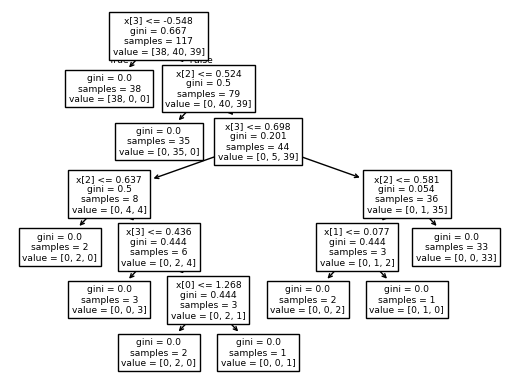

In [63]:
plot_tree(dtc)

In [64]:
y_pred = dtc.predict(X_test)
accuracy_score(y_test,y_pred)

0.9666666666666667